In [2]:
# imports Libraries
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import CLEANED_DATA_PATH, FIGURES_DIR

sns.set_style("whitegrid")

In [3]:
# Load Cleaned Data
df = pd.read_csv(CLEANED_DATA_PATH)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ChurnFlag
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


In [4]:
# Target Overview
churn_counts = df["Churn"].value_counts()
churn_pct = df["Churn"].value_counts(normalize=True) * 100

print(churn_counts)
print(churn_pct)

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


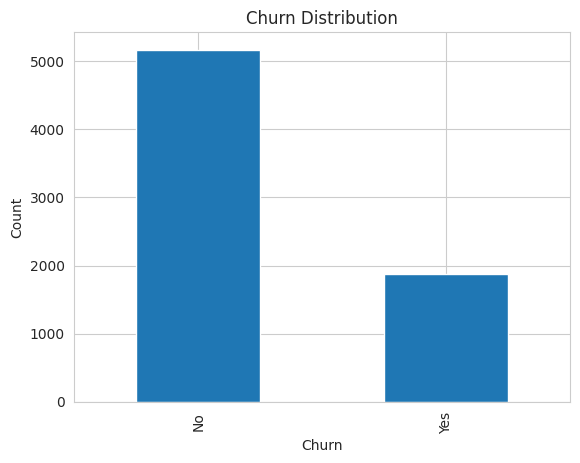

In [5]:
# Visualize Churn Distribution
plt.figure()
df["Churn"].value_counts().plot(kind="bar")
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.savefig(FIGURES_DIR / "churn_distribution.png")
plt.show()

Insight
- About ~26–27% customers churn
- This is not extremely imbalanced, but still important

In [6]:
# Demographic Analysis
pd.crosstab(df["gender"], df["Churn"], normalize="index") * 100

Churn,No,Yes
gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338


Insight:

- Usually no strong difference

In [7]:
# SeniorCitizen
pd.crosstab(df["SeniorCitizen"], df["Churn"], normalize="index") * 100

Churn,No,Yes
SeniorCitizen,,
No,76.393832,23.606168
Yes,58.318739,41.681261


Insight:
- Seniors typically churn more → vulnerability group

In [8]:
# Partner / Dependents

pd.crosstab(df["Partner"], df["Churn"], normalize="index") * 100
pd.crosstab(df["Dependents"], df["Churn"], normalize="index") * 100

Churn,No,Yes
Dependents,,
No,68.720860,31.279140
Yes,84.549763,15.450237


In [9]:
# Service Usage Analysis
services = [
    "PhoneService", "MultipleLines", "InternetService",
    "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport",
    "StreamingTV", "StreamingMovies"
]

for col in services:
    print("\n", col)
    print(pd.crosstab(df[col], df["Churn"], normalize="index") * 100)


 PhoneService
Churn                No        Yes
PhoneService                      
No            75.073314  24.926686
Yes           73.290363  26.709637

 MultipleLines
Churn                    No        Yes
MultipleLines                         
No                74.955752  25.044248
No phone service  75.073314  24.926686
Yes               71.390104  28.609896

 InternetService
Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980

 OnlineSecurity
Churn                       No        Yes
OnlineSecurity                           
No                   58.233276  41.766724
No internet service  92.595020   7.404980
Yes                  85.388806  14.611194

 OnlineBackup
Churn                       No        Yes
OnlineBackup                             
No                   60.071244  39.928756
No internet service  92.595020   7.404980
Yes             

Key insights:

- ❗ Customers without OnlineSecurity churn much more
- ❗ Customers without TechSupport churn much more
- Fiber users often churn more than DSL

In [10]:
# Contract & Payment
pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


Insight:

- ❗ Month-to-month customers churn massively more

In [11]:
# Payment Method
pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index") * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


Insight:

- ❗ Electronic check users churn more

In [12]:
# Paperless Billing
pd.crosstab(df["PaperlessBilling"], df["Churn"], normalize="index") * 100

Churn,No,Yes
PaperlessBilling,,
No,83.669916,16.330084
Yes,66.434908,33.565092


Financial Analysis

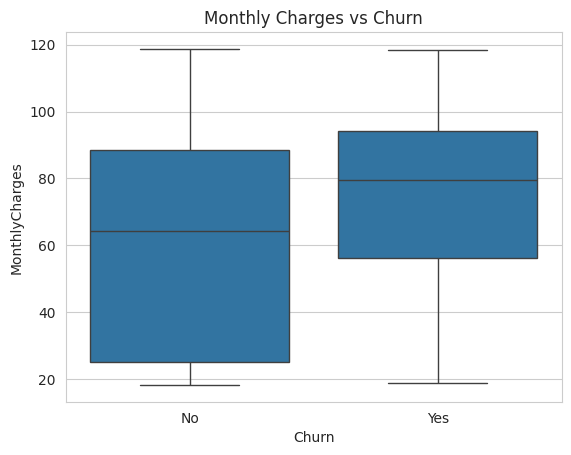

In [13]:
# Monthly Charges
plt.figure()
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges vs Churn")
plt.savefig(FIGURES_DIR / "monthly_charges_vs_churn.png")
plt.show()

Insight:
- Higher charges often = higher churn

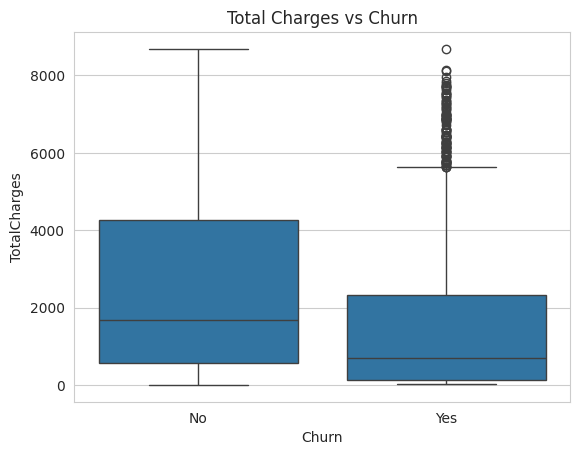

In [ ]:
# Total Charges
plt.figure()
sns.boxplot(x="Churn", y="TotalCharges", data=df)
plt.title("Total Charges vs Churn")
plt.savefig(FIGURES_DIR / "total_charges_vs_churn.png")
plt.show()

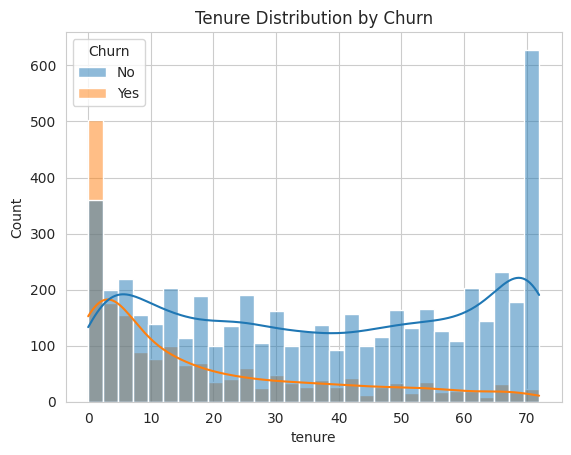

In [15]:
# Tenure Analysis
plt.figure()
sns.histplot(data=df, x="tenure", hue="Churn", bins=30, kde=True)
plt.title("Tenure Distribution by Churn")
plt.savefig(FIGURES_DIR / "tenure_vs_churn.png")
plt.show()

Insight:

- ❗ New customers churn much more
- Long-tenure customers are stable

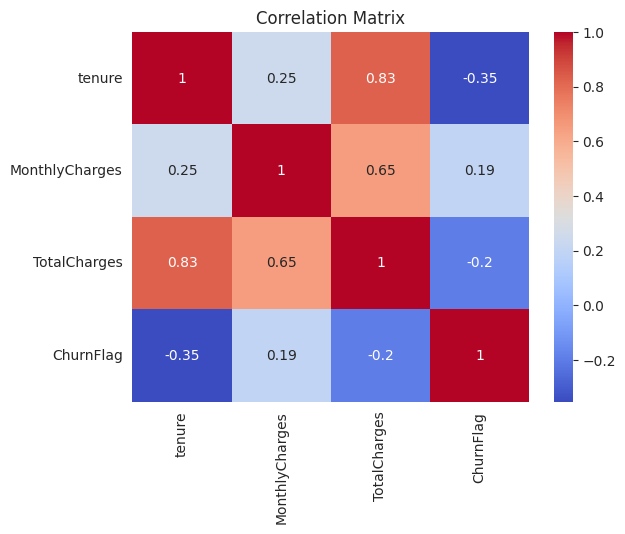

In [ ]:
# Correclation (Numerical Only)
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges", "ChurnFlag"]

corr = df[numeric_cols].corr()

plt.figure()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.savefig(FIGURES_DIR / "correlation_matrix.png")
plt.show()

In [17]:
# Revenue at Risk
churned_customers = df[df["Churn"] == "Yes"]
revenue_at_risk = churned_customers["MonthlyCharges"].sum()
print("Estimated Monthly Revenue at Risk:", revenue_at_risk)

Estimated Monthly Revenue at Risk: 139130.85


## Key Business Insights

1. Contract type is the strongest churn driver:
   - Month-to-month customers have significantly higher churn rates
   - Long-term contracts reduce churn

2. Customer tenure is critical:
   - New customers are at highest risk
   - Retention efforts should focus on early lifecycle

3. Service-related drivers:
   - Customers without OnlineSecurity and TechSupport churn more
   - These services increase stickiness

4. Payment behavior:
   - Electronic check users show higher churn
   - Indicates possible friction or lower engagement

5. Financial patterns:
   - Higher monthly charges are associated with higher churn
   - Suggests perceived lack of value

6. Revenue risk:
   - A significant portion of revenue comes from customers at risk of churn
   - Prioritization strategy is required